# Colab OCR + Box Visualization (Baybayin, Offline Ready)

This notebook mirrors the Colab workflow while ensuring dependencies are only downloaded when missing, so after the initial setup you can run the OCR + box visualization steps fully offline.

In [4]:
# --- STEP 1: Installation ---
import os
import shutil
import subprocess
import sys
from importlib import metadata
from pathlib import Path

print("📦 Checking required system and Python packages...")

APT_PACKAGES = [
    ("tesseract-ocr", "Tesseract OCR engine"),
    ("libtesseract-dev", "Tesseract development headers"),
    ("libleptonica-dev", "Leptonica imaging library"),
]

def command_exists(name: str) -> bool:
    return shutil.which(name) is not None

def apt_package_installed(pkg: str) -> bool:
    if not command_exists("dpkg"):
        return False
    return subprocess.run(
        ["dpkg", "-s", pkg],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        check=False,
    ).returncode == 0

missing_apt = [pkg for pkg, _ in APT_PACKAGES if not apt_package_installed(pkg)]

if missing_apt:
    if not command_exists("apt-get"):
        print("⚠️  apt-get is not available on this system.")
        print("    Install these packages manually:", ", ".join(missing_apt))
    else:
        print(f"Installing apt packages only if missing: {', '.join(missing_apt)}")
        subprocess.run(["apt-get", "update", "-qq"], check=False)
        install_cmd = ["apt-get", "install", "-y"] + missing_apt
        try:
            subprocess.run(install_cmd, check=True)
        except subprocess.CalledProcessError as exc:
            print(f"⚠️  apt-get install failed ({exc}). Install the packages manually.")
else:
    print("✅ All apt packages already installed.")

print("\n🐍 Checking pip packages...")

PY_PACKAGES = [
    {"pip": "pytesseract", "import": "pytesseract"},
    {"pip": "pillow", "import": "PIL", "version": "10.4.0"},
    {"pip": "opencv-python-headless", "import": "cv2"},
    {"pip": "pandas", "import": "pandas", "version": "2.2.2"},
    {"pip": "numpy", "import": "numpy", "version": "1.26.4"},
]

def package_needs_install(pkg_info: dict) -> bool:
    pip_name = pkg_info["pip"]
    required_version = pkg_info.get("version")
    try:
        installed_version = metadata.version(pip_name)
    except metadata.PackageNotFoundError:
        print(f"- {pip_name} is not installed.")
        return True
    else:
        if required_version and installed_version != required_version:
            print(f"- {pip_name} {installed_version} found; target {required_version}.")
            return True
        print(f"- {pip_name} {installed_version} already satisfies the requirement.")
        return False

pip_requirements = []
for pkg in PY_PACKAGES:
    if package_needs_install(pkg):
        requirement = f"{pkg['pip']}=={pkg['version']}" if pkg.get("version") else pkg["pip"]
        pip_requirements.append(requirement)

if pip_requirements:
    print("Installing the missing pip packages...")
    install_cmd = [sys.executable, "-m", "pip", "install", "--quiet"] + pip_requirements
    try:
        subprocess.run(install_cmd, check=True)
    except subprocess.CalledProcessError as exc:
        print(f"⚠️  pip install failed ({exc}). Run the command manually if needed.")
else:
    print("✅ All pip packages already match the requested versions.")

print("\nIf you still see import errors, restart the runtime before moving on.")

📦 Checking required system and Python packages...
✅ All apt packages already installed.

🐍 Checking pip packages...
- pytesseract is not installed.
- pillow 11.3.0 found; target 10.4.0.
- opencv-python-headless is not installed.
- pandas 2.3.3 found; target 2.2.2.
- numpy 2.2.6 found; target 1.26.4.
Installing the missing pip packages...


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.



If you still see import errors, restart the runtime before moving on.


In [5]:
# --- STEP 2: Imports ---
import glob
import os
import shutil
import subprocess
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import pytesseract
from PIL import Image, ImageDraw, ImageFont
from pytesseract import Output

try:
    from google.colab.patches import cv2_imshow  # type: ignore
except ImportError:
    from IPython.display import display

    def cv2_imshow(image):
        if image.ndim == 2:
            display(Image.fromarray(image))
        else:
            rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            display(Image.fromarray(rgb))

print("✅ Imports complete.")
print(f"numpy {np.__version__}")
print(f"pandas {pd.__version__}")
print(f"opencv {cv2.__version__}")
print(f"pytesseract {pytesseract.__version__}")

✅ Imports complete.
numpy 1.26.4
pandas 2.2.2
opencv 4.11.0
pytesseract 0.3.13


In [22]:
# --- STEP 3: Paths / Config ---
BASE_DIR = Path(os.environ.get("BAYBAYIN_WORKDIR", Path.cwd()))
IMG_DIR = Path(os.environ.get("BAYBAYIN_IMG_DIR", BASE_DIR / "sample_baybayin_images"))
OUTPUT_DIR = Path(os.environ.get("BAYBAYIN_OUTPUT_DIR", BASE_DIR / "annotated_output"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXTS = ("*.PNG", "*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff")
LANG = os.environ.get("BAYBAYIN_LANG", "baybayin")
DEFAULT_PSM = int(os.environ.get("BAYBAYIN_PSM", "6"))
CONFIG = None
DETECTED_OEM = None
CONF_THRESHOLD = float(os.environ.get("BAYBAYIN_CONF_THRESHOLD", "70.0"))
USER_FONT_PATH = Path(os.environ.get("BAYBAYIN_FONT_PATH", BASE_DIR / "NotoSansTagalog-Regular.ttf"))
DEFAULT_TRAINEDDATA = BASE_DIR / "releases" / "best_three" / "dataset_stage3_balanced_large0.047_17118" / "dataset_stage3_balanced_large0.047_17118.traineddata"
USER_TRAINEDDATA_PATH = Path(os.environ.get("BAYBAYIN_TRAINEDDATA", DEFAULT_TRAINEDDATA))


print(f"📁 Image directory: {IMG_DIR}")
print(f"📁 Output directory: {OUTPUT_DIR}")
print(f"🗂️  Image patterns: {EXTS}")
print(f"🈶  Target language: {LANG}")
print(f"🎯 Confidence threshold: {CONF_THRESHOLD}")
print(f"🔤 Font path: {USER_FONT_PATH if USER_FONT_PATH.exists() else 'Font not found, default will be used.'}")
print(f"📦 Traineddata source: {USER_TRAINEDDATA_PATH if USER_TRAINEDDATA_PATH.exists() else 'Update USER_TRAINEDDATA_PATH / BAYBAYIN_TRAINEDDATA.'}")

📁 Image directory: /home/kmbandillo/baybayin_project/sample_baybayin_images
📁 Output directory: /home/kmbandillo/baybayin_project/annotated_output
🗂️  Image patterns: ('*.PNG', '*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.tiff')
🈶  Target language: baybayin
🎯 Confidence threshold: 70.0
🔤 Font path: /home/kmbandillo/baybayin_project/NotoSansTagalog-Regular.ttf
📦 Traineddata source: /home/kmbandillo/baybayin_project/releases/best_three/dataset_stage3_balanced_large0.047_17118/dataset_stage3_balanced_large0.047_17118.traineddata


In [23]:
# --- STEP 4: Install Baybayin Traineddata ---
print("🔧 Setting up Baybayin language model...")

USER_TESSDATA_DIR = Path(os.environ.get("BAYBAYIN_TESSDATA_DIR", Path.home() / ".local/share/tessdata"))
CONFIG_TESSDATA = ""

def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path

def find_tessdata_dir() -> Path:
    env_dir = os.environ.get("TESSDATA_PREFIX")
    if env_dir:
        return ensure_dir(Path(env_dir))
    candidates = [
        "/usr/share/tesseract-ocr/4.00/tessdata",
        "/usr/share/tesseract-ocr/5/tessdata",
        "/usr/share/tessdata",
    ]
    for candidate in candidates:
        path = Path(candidate)
        if path.exists() and os.access(path, os.W_OK):
            return path
    return ensure_dir(USER_TESSDATA_DIR)

tessdata_dir = find_tessdata_dir()
CONFIG_TESSDATA = f'--tessdata-dir "{tessdata_dir}"'
print(f"Tessdata directory resolved to: {tessdata_dir}")

traineddata_src = USER_TRAINEDDATA_PATH
traineddata_dst = tessdata_dir / f"{LANG}.traineddata"


def copy_traineddata(src: Path, dst: Path) -> None:
    if src.resolve() == dst.resolve() and dst.exists():
        print("✅ baybayin.traineddata already resides in the tessdata directory.")
        return
    shutil.copy(src, dst)
    print(f"✅ Copied {src} -> {dst}")

if traineddata_src.exists():
    try:
        copy_traineddata(traineddata_src, traineddata_dst)
    except PermissionError:
        fallback_dir = ensure_dir(USER_TESSDATA_DIR)
        fallback_dst = fallback_dir / f"{LANG}.traineddata"
        print(f"⚠️ Permission denied for {traineddata_dst}. Using {fallback_dst} instead.")
        copy_traineddata(traineddata_src, fallback_dst)
        tessdata_dir = fallback_dir
        CONFIG_TESSDATA = f'--tessdata-dir "{tessdata_dir}"'
else:
    print(f"⚠️ Traineddata not found at {traineddata_src}. Upload the file and update USER_TRAINEDDATA_PATH if needed.")

try:
    version_output = subprocess.run(["tesseract", "--version"], capture_output=True, text=True, check=False)
    if version_output.stdout:
        print("Tesseract version info:")
        print(version_output.stdout.splitlines()[0])
except FileNotFoundError:
    print("⚠️ Tesseract binary not found on PATH.")

try:
    available_langs = pytesseract.get_languages(config=CONFIG_TESSDATA)
    print(f"🔎 Available languages: {', '.join(sorted(available_langs))}")
    if LANG in available_langs:
        print(f"✅ '{LANG}' language is ready.")
    else:
        print(f"⚠️ '{LANG}' not found. Copy the traineddata above and rerun this cell.")
except pytesseract.pytesseract.TesseractNotFoundError as exc:
    print(f"⚠️ Could not list languages: {exc}")
    available_langs = []


def detect_oem(lang: str, psm: int):
    dummy = np.full((80, 240), 255, dtype=np.uint8)
    cv2.putText(dummy, "BAYBAYIN", (5, 55), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,), 2, cv2.LINE_AA)
    for oem in (1, 3, 2, 0):
        try:
            pytesseract.image_to_string(dummy, lang=lang, config=f"{CONFIG_TESSDATA} --oem {oem} --psm {psm}".strip())
            return oem
        except pytesseract.TesseractError:
            continue
    return None

if 'available_langs' in globals() and LANG in available_langs:
    DETECTED_OEM = detect_oem(LANG, DEFAULT_PSM)
    if DETECTED_OEM is not None:
        CONFIG = f"{CONFIG_TESSDATA} --oem {DETECTED_OEM} --psm {DEFAULT_PSM}".strip()
        print(f"✅ Using detected OEM={DETECTED_OEM} with config '{CONFIG}'.")
    else:
        CONFIG = f"{CONFIG_TESSDATA} --psm {DEFAULT_PSM}".strip()
        print(f"⚠️ Could not detect a working OEM. Falling back to '{CONFIG}'.")
else:
    CONFIG = f"{CONFIG_TESSDATA} --psm {DEFAULT_PSM}".strip()
    print(f"⚠️ Language '{LANG}' is not yet available. Using fallback config '{CONFIG}'.")


🔧 Setting up Baybayin language model...
Tessdata directory resolved to: /home/kmbandillo/.local/share/tessdata
✅ Copied /home/kmbandillo/baybayin_project/releases/best_three/dataset_stage3_balanced_large0.047_17118/dataset_stage3_balanced_large0.047_17118.traineddata -> /home/kmbandillo/.local/share/tessdata/baybayin.traineddata
Tesseract version info:
tesseract 4.1.1
🔎 Available languages: baybayin
✅ 'baybayin' language is ready.
✅ Using detected OEM=1 with config '--tessdata-dir "/home/kmbandillo/.local/share/tessdata" --oem 1 --psm 6'.


In [24]:
# --- STEP 5: OCR + Box Visualization Helpers ---
from typing import Iterable, List

print("⚙️  Preparing helper functions...")

def collect_images(directory: Path, patterns: Iterable[str]) -> List[Path]:
    image_paths: List[Path] = []
    for pattern in patterns:
        image_paths.extend(sorted(directory.glob(pattern)))
    return image_paths

def load_user_font(font_path: Path, size: int = 18):
    if font_path and font_path.exists():
        try:
            return ImageFont.truetype(str(font_path), size)
        except OSError as exc:
            print(f"⚠️ Could not load font '{font_path}': {exc}. Using default font instead.")
    return ImageFont.load_default()

def annotate_boxes(bgr_image: np.ndarray, rows: pd.DataFrame, font) -> np.ndarray:
    annotated = bgr_image.copy()
    rows_iter = list(rows.itertuples())
    if not rows_iter:
        return annotated

    for row in rows_iter:
        x, y, w, h = int(row.left), int(row.top), int(row.width), int(row.height)
        cv2.rectangle(annotated, (x, y), (x + w, y + h), (0, 165, 255), 2)

    pil_image = Image.fromarray(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(pil_image)

    for row in rows_iter:
        x, y = int(row.left), int(row.top)
        conf = float(row.conf)
        label = row.text if isinstance(row.text, str) and row.text else "(blank)"
        draw.text((x, max(0, y - 20)), f"{label} [{conf:.1f}]", fill=(255, 165, 0), font=font)

    return cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)

def run_ocr_pipeline(img_dir: Path = IMG_DIR, output_dir: Path = OUTPUT_DIR, show_preview: bool = True) -> pd.DataFrame:
    images = collect_images(img_dir, EXTS)
    if not images:
        print(f"⚠️ No images found in {img_dir}. Update IMG_DIR or add samples.")
        return pd.DataFrame()

    font = load_user_font(USER_FONT_PATH)
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"Processing {len(images)} image(s)...")
    summary_rows = []

    for image_path in images:
        print(f"📄 {image_path}")
        bgr = cv2.imread(str(image_path))
        if bgr is None:
            print("   ⚠️ Could not read this file, skipping.")
            continue

        data = pytesseract.image_to_data(bgr, lang=LANG, config=CONFIG, output_type=Output.DATAFRAME)
        if data.empty:
            print("   ⚠️ No OCR data returned.")
            continue

        data = data.copy()
        data["text"] = data["text"].fillna("").astype(str).str.strip()
        data = data[data["text"] != ""]
        data["conf"] = pd.to_numeric(data["conf"], errors="coerce")
        valid = data[data["conf"] >= CONF_THRESHOLD].copy()

        annotated = annotate_boxes(bgr, valid, font)
        output_path = output_dir / f"{image_path.stem}_annotated.png"
        cv2.imwrite(str(output_path), annotated)

        if show_preview:
            cv2_imshow(annotated)

        summary_rows.append(
            {
                "image": str(image_path),
                "output_image": str(output_path),
                "boxes_drawn": int(len(valid)),
                "mean_conf": float(valid["conf"].mean()) if not valid.empty else None,
                "min_conf": float(valid["conf"].min()) if not valid.empty else None,
                "max_conf": float(valid["conf"].max()) if not valid.empty else None,
            }
        )

    summary_df = pd.DataFrame(summary_rows)
    if not summary_df.empty:
        csv_path = output_dir / "ocr_summary.csv"
        summary_df.to_csv(csv_path, index=False)
        print(f"📊 Summary saved to {csv_path}")
    else:
        print("⚠️ Nothing was processed; check your configuration.")

    return summary_df

⚙️  Preparing helper functions...


Processing 18 image(s)...
📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/BAKLAYON.png


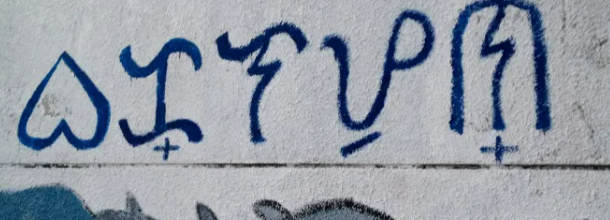

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/Baybayin_GWAPO_20260201T015834.png


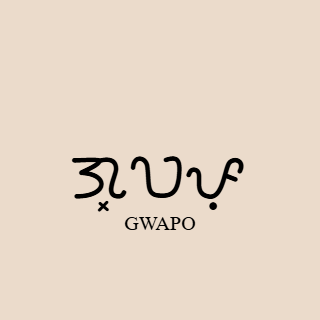

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/Screenshot 2026-01-27 051924.png


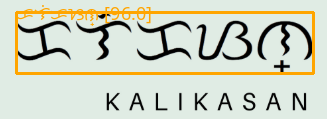

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/Screenshot 2026-01-27 055015.png


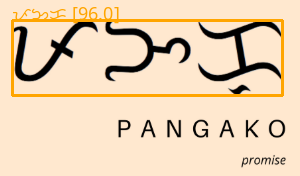

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/Screenshot 2026-01-27 055021.png


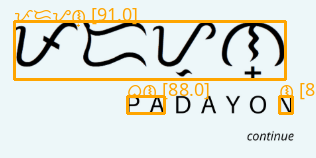

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/Screenshot 2026-02-01 015411.png


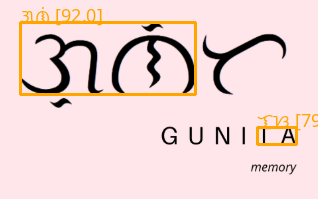

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/Screenshot 2026-02-01 015422.png


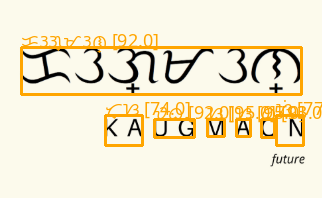

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/Screenshot 2026-02-01 015443.png


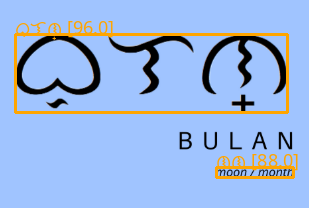

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/Screenshot 2026-02-01 015934.png


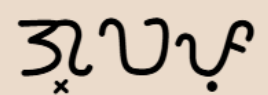

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/Screenshot 2026-02-01 020907.png


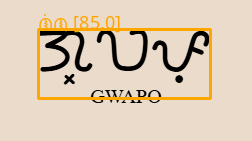

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/alon.png


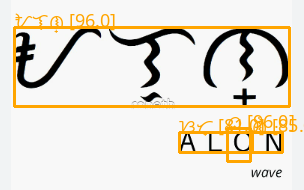

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/balantag.png


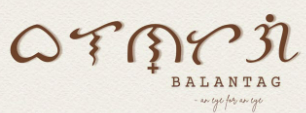

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/baybayin (2).png


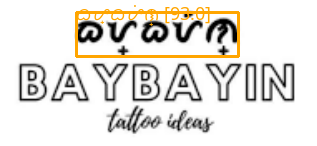

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/baybayin.png


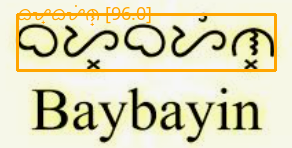

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/baybayin_namin_words-2795.tif


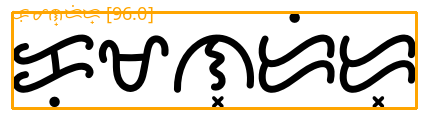

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/baybayin_namin_words-2796.tif


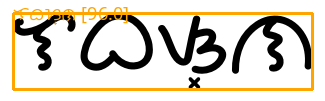

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/baybayin_namin_words-2797.tif


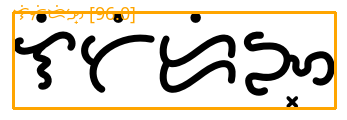

📄 /home/kmbandillo/baybayin_project/sample_baybayin_images/baybayin_namin_words-2798.tif


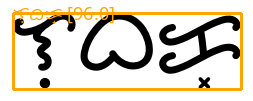

📊 Summary saved to /home/kmbandillo/baybayin_project/annotated_output/ocr_summary.csv


,image,output_image,boxes_drawn,mean_conf,min_conf,max_conf
0,/home/kmbandillo/baybayin_project/sample_bayba...,/home/kmbandillo/baybayin_project/annotated_ou...,0,NaN,NaN,NaN
1,/home/kmbandillo/baybayin_project/sample_bayba...,/home/kmbandillo/baybayin_project/annotated_ou...,0,NaN,NaN,NaN
2,/home/kmbandillo/baybayin_project/sample_bayba...,/home/kmbandillo/baybayin_project/annotated_ou...,1,96.000000,96.0,96.0
3,/home/kmbandillo/baybayin_project/sample_bayba...,/home/kmbandillo/baybayin_project/annotated_ou...,1,96.000000,96.0,96.0
4,/home/kmbandillo/baybayin_project/sample_bayba...,/home/kmbandillo/baybayin_project/annotated_ou...,3,86.666667,81.0,91.0
5,/home/kmbandillo/baybayin_project/sample_bayba...,/home/kmbandillo/baybayin_project/annotated_ou...,2,85.500000,79.0,92.0
6,/home/kmbandillo/baybayin_project/sample_bayba...,/home/kmbandillo/baybayin_project/annotated_ou...,7,88.285714,74.0,95.0
7,/home/kmbandillo/baybayin_project/sample_bayba...,/home/kmbandillo/baybayin_project/annotated_ou...,2,92.000000,88.0,96.0
8,/home/kmbandillo/baybayin_project/sample_bayba...,/home/kmbandillo/baybayin_project/annotated_ou...,0,NaN,NaN,NaN
9,/home/kmbandillo/baybayin_project/sample_bayba...,/home/kmbandillo/baybayin_project/annotated_ou...,1,85.000000,85.0,85.0


In [25]:
# --- STEP 6: Run the Pipeline ---
summary = run_ocr_pipeline()
summary